In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
image = cv2.imread('lena.bmp')

In [36]:
def compute_histogram(image):
    # 计算直方图
    hist_b = cv2.calcHist([image], [0], None, [256], [0, 256])  # 蓝色通道
    hist_g = cv2.calcHist([image], [1], None, [256], [0, 256])  # 绿色通道
    hist_r = cv2.calcHist([image], [2], None, [256], [0, 256])  # 红色通道
    
    

    # 绘制直方图
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.subplot(1,2,2)
    plt.plot(hist_b, color='blue', label='Blue Channel')
    plt.plot(hist_g, color='green', label='Green Channel')
    plt.plot(hist_r, color='red', label='Red Channel')
    plt.title('Histogram')
    plt.legend()
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

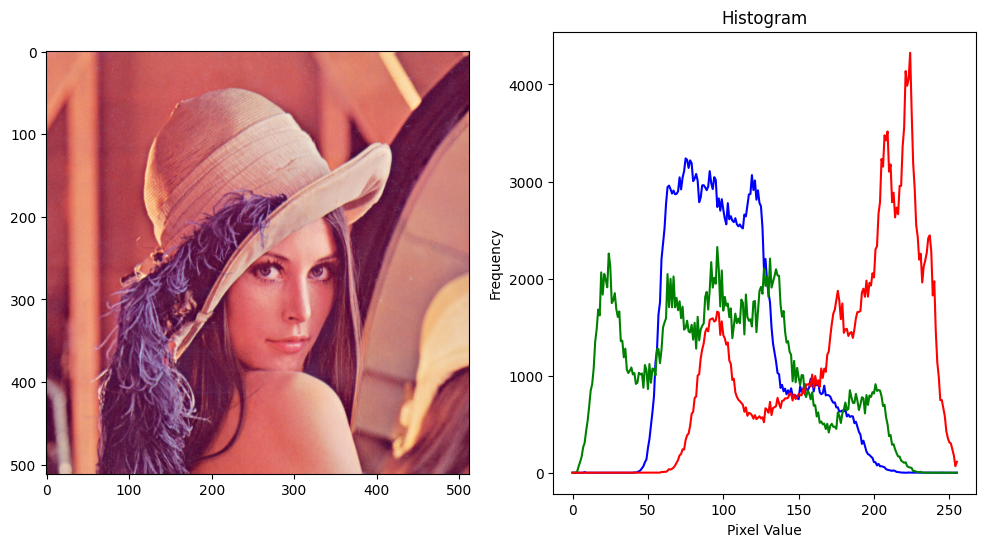

In [31]:
compute_histogram(image)

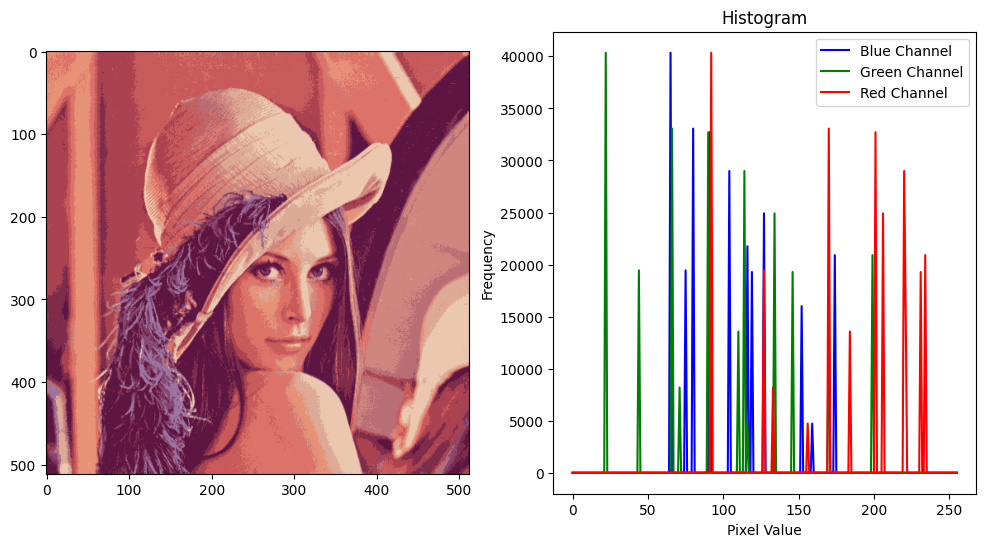

In [37]:
def quantize_colors(image, num_colors=12):
    # 将图像数据展平成二维数组，并使用k-means进行颜色量化
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    
    # 使用k-means算法量化颜色
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(Z, num_colors, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # 将图像重新构建为量化后的颜色
    quantized_image = centers[labels.flatten()]
    quantized_image = quantized_image.reshape(image.shape)
    
    return quantized_image.astype(np.uint8)

# 量化RGB颜色空间中的颜色
quantized_image = quantize_colors(image, num_colors=12)

# 显示量化后的图像
compute_histogram(quantized_image)

In [16]:
def color_contrast(pixel, global_mean):
    return np.sum((pixel - global_mean) ** 2)

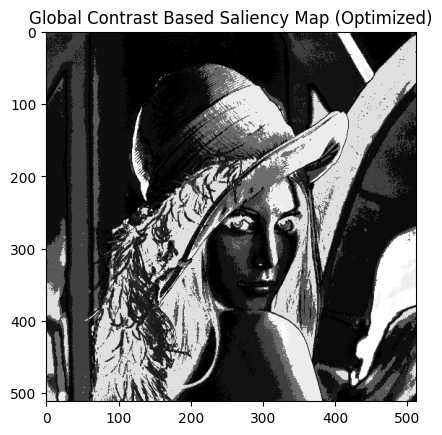

In [18]:
global_mean = np.mean(cv2.cvtColor(optimized_image, cv2.COLOR_BGR2Lab), axis=(0, 1))
saliency_map = np.zeros((optimized_image.shape[0], optimized_image.shape[1]), dtype=np.float32)
for i in range(optimized_image.shape[0]):
    for j in range(optimized_image.shape[1]):
        saliency_map[i, j] = color_contrast(cv2.cvtColor(optimized_image[i, j].reshape(1, 1, 3), cv2.COLOR_BGR2Lab)[0][0], global_mean)
saliency_map = (saliency_map - np.min(saliency_map)) / (np.max(saliency_map) - np.min(saliency_map)) * 255
saliency_map = saliency_map.astype(np.uint8)

# 显示显著性图
plt.imshow(saliency_map, cmap='gray')
plt.title('Global Contrast Based Saliency Map (Optimized)')
plt.show()

In [58]:
import cv2
import numpy as np

def compute_saliency(image_path):
    # 读取图像
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image {image_path} not found")
        return

    # 将图像转换为Lab颜色空间
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # 提取L、A、B通道
    L, A, B = cv2.split(lab_image)
    
    # 计算图像的直方图并归一化
    def calculate_histogram(channel):
        hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
        hist = hist / (channel.shape[0] * channel.shape[1])
        return hist

    L_hist = calculate_histogram(L)
    A_hist = calculate_histogram(A)
    B_hist = calculate_histogram(B)

    # 计算每个像素与其他像素的对比度
    def compute_contrast(channel, hist):
        contrast_map = np.zeros_like(channel, dtype=np.float32)
        for i in range(channel.shape[0]):
            for j in range(channel.shape[1]):
                pixel_value = channel[i, j]
                contrast = 0.0
                for k in range(256):
                    contrast += hist[k] * abs(pixel_value - k)
                contrast_map[i, j] = contrast
        return contrast_map

    # 计算L、A、B通道的对比度
    L_contrast = compute_contrast(L, L_hist)
    A_contrast = compute_contrast(A, A_hist)
    B_contrast = compute_contrast(B, B_hist)

    # 将对比度图叠加，得到最终显著性图
    saliency_map = (L_contrast + A_contrast + B_contrast) / 3

    # 归一化显著性图，使其值在0到255之间
    saliency_map = cv2.normalize(saliency_map, None, 0, 255, cv2.NORM_MINMAX)

    # 转换为uint8类型
    saliency_map = saliency_map.astype(np.uint8)

    return saliency_map

# 使用示例
saliency = compute_saliency('lena.bmp')

plt.imshow(cv2.cvtColor(saliency,cv2.BGR2RGB))
plt.show()

C:\Users\25232\AppData\Local\Temp\ipykernel_5304\929214244.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast_map[i, j] = contrast


AttributeError: module 'cv2' has no attribute 'BGR2RGB'

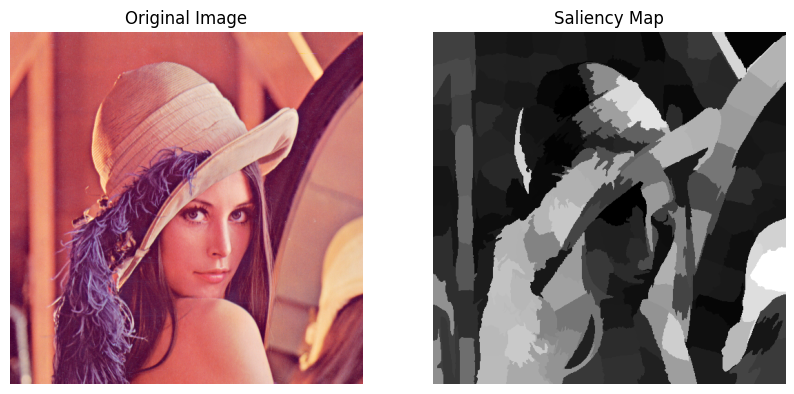

In [2]:
import cv2
import numpy as np
from skimage import segmentation
from skimage.color import rgb2lab
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

def regional_contrast_saliency(image_path):
    # 读取图像
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 将图像转换为Lab颜色空间
    img_lab = rgb2lab(img_rgb)

    # 使用SLIC算法进行超像素分割
    segments = segmentation.slic(img_rgb, n_segments=200, compactness=10, sigma=1)

    # 获取所有超像素的标签
    labels = np.unique(segments)

    # 计算每个超像素的平均颜色（在Lab空间中）
    mean_colors = []
    for label in labels:
        mask = segments == label
        mean_color = img_lab[mask].mean(axis=0)
        mean_colors.append(mean_color)
    mean_colors = np.array(mean_colors)

    # 计算超像素之间的颜色对比度
    contrast = pairwise_distances(mean_colors, metric='euclidean')

    # 对每个超像素计算显著性值
    saliency_values = contrast.sum(axis=1)

    # 归一化显著性值
    saliency_values = (saliency_values - saliency_values.min()) / (saliency_values.max() - saliency_values.min())

    # 创建显著性图
    saliency_map = np.zeros(img_rgb.shape[:2])
    for label, saliency in zip(labels, saliency_values):
        saliency_map[segments == label] = saliency

    # 将显著性图转换为0-255的范围
    saliency_map = (saliency_map * 255).astype(np.uint8)

    return img_rgb, saliency_map

# 使用示例
if __name__ == "__main__":
    image_path = 'lena.bmp'  # 请将此路径替换为您的图像路径
    original_image, saliency_map = regional_contrast_saliency(image_path)

    # 使用Matplotlib显示原始图像和显著性图
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(original_image)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(saliency_map, cmap='gray')
    ax[1].set_title('Saliency Map')
    ax[1].axis('off')

    plt.show()
